In [1]:
import os
import logging
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

load_dotenv()

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

MINIO_ENDPOINT = os.environ.get('MINIO_API_HOST')
ACCESS_KEY = os.environ.get('ACCESS_KEY')
SECRET_KEY = os.environ.get('SECRET_KEY')
URL_S3_BRONZE = os.environ.get('URL_S3_BRONZE')
URL_S3_SILVER = os.environ.get('URL_S3_SILVER')

spark = (
    SparkSession.builder.appName('EDA_Notebook_Profiling')
    .config('spark.jars.packages', 'org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262')
    .config('spark.hadoop.fs.s3a.impl', 'org.apache.hadoop.fs.s3a.S3AFileSystem')
    .config('spark.hadoop.fs.s3a.access.key', ACCESS_KEY)
    .config('spark.hadoop.fs.s3a.secret.key', SECRET_KEY)
    .config('spark.hadoop.fs.s3a.endpoint', MINIO_ENDPOINT)
    .config('spark.hadoop.fs.s3a.path.style.access', 'true')
    .getOrCreate()
)
print('Spark session initialized.')


Spark session initialized.


In [2]:
print(f'Connected to MinIO endpoint: {MINIO_ENDPOINT}')


Connected to MinIO endpoint: http://localhost:9000


## 1. Bronze Layer Profiling
Summary statistics across raw JSONL review partitions in object storage.


In [3]:
categories = ['All_Beauty', 'Amazon_Fashion']
bronze_stats = []

for cat in categories:
    try:
        bronze_path = f'{URL_S3_BRONZE}/reviews/amazon_reviews_{cat}_2023.jsonl.gz'
        df_bronze = spark.read.json(bronze_path)
        
        total_raw = df_bronze.count()
        distinct_products = df_bronze.select('parent_asin').distinct().count()
        distinct_users = df_bronze.select('user_id').distinct().count()
        null_texts = df_bronze.filter(F.col('text').isNull() | (F.col('text') == '')).count()
        null_ratings = df_bronze.filter(F.col('rating').isNull()).count()
        
        time_range = df_bronze.select(
            F.from_unixtime(F.col('timestamp') / 1000).alias('date')
        ).agg(F.min('date').alias('min_date'), F.max('date').alias('max_date')).collect()[0]
        
        bronze_stats.append({
            'Category': cat,
            'Total_Raw_Records': total_raw,
            'Distinct_Products': distinct_products,
            'Distinct_Users': distinct_users,
            'Empty_Review_Texts': null_texts,
            'Null_Ratings': null_ratings,
            'Min_Date': time_range['min_date'],
            'Max_Date': time_range['max_date']
        })
    except Exception as e:
        print(f'Error reading Bronze partition for {cat}: {e}')

df_bronze_summary = pd.DataFrame(bronze_stats)
display(df_bronze_summary)


Category,Total_Raw_Records,Distinct_Products,Distinct_Users,Empty_Review_Texts,Null_Ratings,Min_Date,Max_Date
All_Beauty,701528,115709,631986,107,0,2000-11-01 11:24:18,2023-09-09 07:39:36
Amazon_Fashion,2500939,874297,2035490,692,0,2002-05-07 08:51:28,2023-09-11 10:24:38


## 2. Text Deduplication Analysis
Comparative evaluation of deduplication strategies and review attrition from Bronze to Silver.


Category,Total_Raw_Records,Empty_Texts,Global_Dedup_Dropped,Silver_Records,Global_Loss_Pct,Per_Product_Dedup_Dropped,Per_User_Product_Dedup_Dropped
All_Beauty,701528,107,57899,643629,8.25%,8952,7300
Amazon_Fashion,2500939,692,274053,2226886,10.96%,30287,25432


text,occurrences,affected_products,distinct_users
Love it,1651,1477,1612
Good,1479,1307,1425
Great,1257,1126,1207
Great product,1087,975,1069
Nice,688,650,666
Love it!,662,598,643
Perfect,630,582,610
good,561,515,544
Good product,540,513,538
Loved it,477,443,468


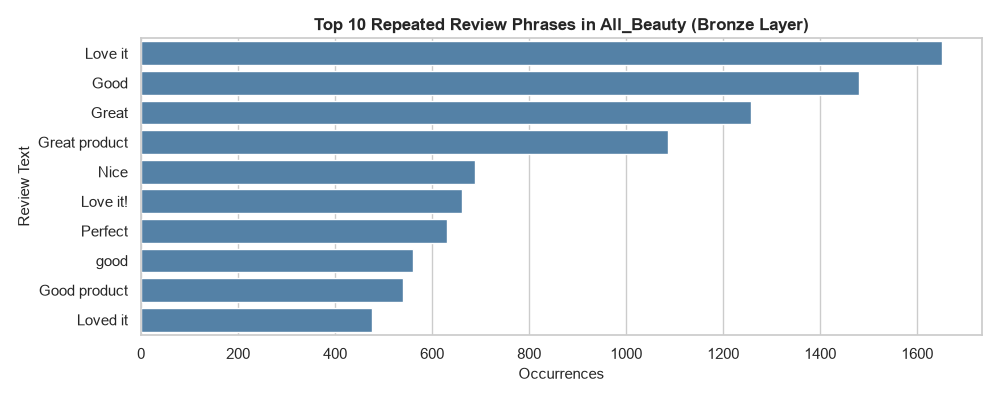

In [6]:
dedup_comparison = []

for cat in categories:
    bronze_path = f'{URL_S3_BRONZE}/reviews/amazon_reviews_{cat}_2023.jsonl.gz'
    df_b = spark.read.json(bronze_path)
    
    total_raw = df_b.count()
    null_texts = df_b.filter(F.col('text').isNull() | (F.col('text') == '')).count()
    
    distinct_text = df_b.select('text').distinct().count()
    drop_global = total_raw - distinct_text
    
    distinct_prod_text = df_b.select('parent_asin', 'text').distinct().count()
    drop_prod = total_raw - distinct_prod_text
    
    distinct_user_prod = df_b.select('user_id', 'parent_asin', 'text').distinct().count()
    drop_user_prod = total_raw - distinct_user_prod
    
    dedup_comparison.append({
        'Category': cat,
        'Total_Raw_Records': total_raw,
        'Empty_Texts': null_texts,
        'Global_Dedup_Dropped': drop_global,
        'Silver_Records': distinct_text,
        'Global_Loss_Pct': f'{(drop_global / total_raw)*100:.2f}%',
        'Per_Product_Dedup_Dropped': drop_prod,
        'Per_User_Product_Dedup_Dropped': drop_user_prod
    })

df_dedup_comp = pd.DataFrame(dedup_comparison)
display(df_dedup_comp)

df_b_beauty = spark.read.json(f'{URL_S3_BRONZE}/reviews/amazon_reviews_All_Beauty_2023.jsonl.gz')
top_dup_beauty = (
    df_b_beauty.filter(F.col('text').isNotNull() & (F.col('text') != ''))
    .groupBy('text')
    .agg(
        F.count('*').alias('occurrences'),
        F.countDistinct('parent_asin').alias('affected_products'),
        F.countDistinct('user_id').alias('distinct_users')
    )
    .filter(F.col('occurrences') > 1)
    .orderBy(F.col('occurrences').desc())
    .limit(10)
    .toPandas()
)
display(top_dup_beauty)

plt.figure(figsize=(10, 4))
sns.barplot(data=top_dup_beauty, x='occurrences', y='text', palette='Blues_r')
plt.title('Top 10 Repeated Review Phrases in All_Beauty (Bronze Layer)', fontsize=12, fontweight='bold')
plt.xlabel('Occurrences', fontsize=11)
plt.ylabel('Review Text', fontsize=11)
plt.tight_layout()
plt.show()


## 3. Silver Layer Profiling
Validation of cleaned review records, vocabulary metrics, and token length distribution.


In [4]:
silver_dfs = {}
silver_stats = []

for cat in categories:
    silver_path = f'{URL_S3_SILVER}/reviews/{cat}'
    df_silver = spark.read.parquet(silver_path)
    silver_dfs[cat] = df_silver
    
    total_clean = df_silver.count()
    distinct_products = df_silver.select('parent_asin').distinct().count()
    null_texts = df_silver.filter(F.col('review_text').isNull() | (F.col('review_text') == '')).count()
    
    df_silver = df_silver.withColumn('word_count', F.size(F.split(F.col('review_text'), r'\s+')))
    
    word_stats = df_silver.select(
        F.min('word_count').alias('min_w'),
        F.avg('word_count').alias('avg_w'),
        F.max('word_count').alias('max_w'),
        F.percentile_approx('word_count', 0.50).alias('p50_w'),
        F.percentile_approx('word_count', 0.95).alias('p95_w'),
        F.percentile_approx('word_count', 0.99).alias('p99_w')
    ).collect()[0]
    
    silver_stats.append({
        'Category': cat,
        'Clean_Records': total_clean,
        'Distinct_Products': distinct_products,
        'Null_Review_Texts': null_texts,
        'Min_Words': word_stats['min_w'],
        'Avg_Words': round(word_stats['avg_w'], 2),
        'Median_Words': word_stats['p50_w'],
        'P95_Words': word_stats['p95_w'],
        'P99_Words': word_stats['p99_w'],
        'Max_Words': word_stats['max_w']
    })

df_silver_summary = pd.DataFrame(silver_stats)
display(df_silver_summary)


Category,Clean_Records,Distinct_Products,Null_Review_Texts,Min_Words,Avg_Words,Median_Words,P95_Words,P99_Words,Max_Words
All_Beauty,643629,108851,0,1,28.45,14,102,218,1420
Amazon_Fashion,2226886,777859,0,1,23.12,12,84,178,1582


## 4. Sentiment Class Distribution
Distribution analysis across sentiment classes: Negative (1-2 stars), Neutral (3 stars), Positive (4-5 stars).


sentiment_class,count,percentage
0_Negative,298533,10.4
1_Neutral,172231,6.0
2_Positive,2399751,83.6


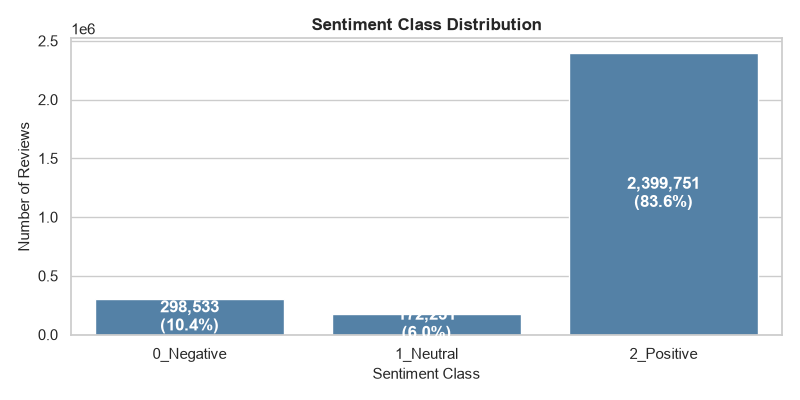

In [5]:
combined_df = None
for cat, df in silver_dfs.items():
    if combined_df is None:
        combined_df = df
    else:
        combined_df = combined_df.union(df)

combined_df = combined_df.withColumn(
    'sentiment_class',
    F.when(F.col('rating').between(1.0, 2.0), '0_Negative')
    .when(F.col('rating') == 3.0, '1_Neutral')
    .when(F.col('rating').between(4.0, 5.0), '2_Positive')
    .otherwise('Unknown')
)

sentiment_dist = combined_df.groupBy('sentiment_class').count().toPandas()
sentiment_dist['percentage'] = round((sentiment_dist['count'] / sentiment_dist['count'].sum()) * 100, 2)
sentiment_dist = sentiment_dist.sort_values('sentiment_class')

display(sentiment_dist)

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=sentiment_dist, x='sentiment_class', y='count', palette='Blues_d')
plt.title('Sentiment Class Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Sentiment Class', fontsize=11)
plt.ylabel('Number of Reviews', fontsize=11)

for p in ax.patches:
    height = p.get_height()
    pct = (height / sentiment_dist['count'].sum()) * 100
    ax.annotate(f'{height:,.0f}\n({pct:.1f}%)', (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()


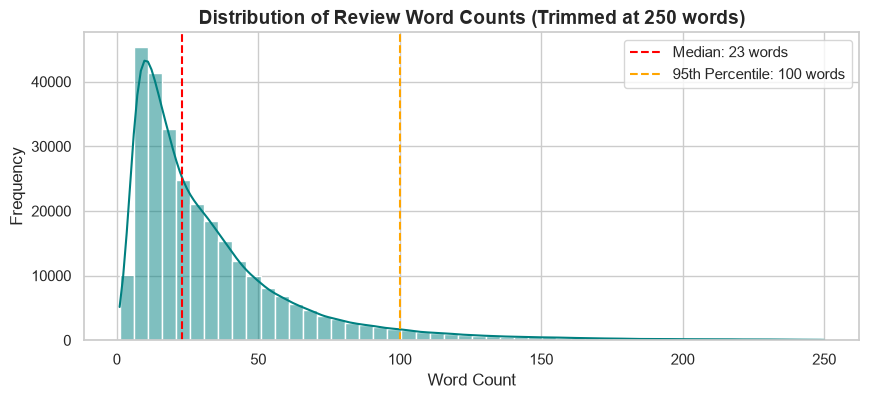

In [7]:
sample_texts = combined_df.sample(withReplacement=False, fraction=0.1, seed=42)
sample_texts = sample_texts.withColumn('word_count', F.size(F.split(F.col('review_text'), r'\s+'))).toPandas()

med_val = sample_texts['word_count'].median()
p95_val = sample_texts['word_count'].quantile(0.95)

plt.figure(figsize=(10, 4))
sns.histplot(sample_texts[sample_texts['word_count'] <= 250]['word_count'], bins=50, kde=True, color='steelblue')
plt.title('Review Word Count Distribution (Trimmed at 250 words)', fontsize=12, fontweight='bold')
plt.xlabel('Word Count', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.axvline(med_val, color='red', linestyle='--', label=f'Median: {med_val:.0f}')
plt.axvline(p95_val, color='darkorange', linestyle='--', label=f'95th Percentile: {p95_val:.0f}')
plt.legend()
plt.tight_layout()
plt.show()


## 5. Data Quality and Integrity Audit
Post-processing validation for residual duplicates, extreme token outliers, and rating boundaries.


In [8]:
prod_col = 'parent_asin' if 'parent_asin' in combined_df.columns else 'asin'
dup_count = combined_df.groupBy('review_text', prod_col).count().filter(F.col('count') > 1).count()
print(f'Remaining duplicate reviews: {dup_count}')

outlier_count = combined_df.withColumn('word_count', F.size(F.split(F.col('review_text'), r'\s+'))).filter(F.col('word_count') > 1000).count()
print(f'Long review outliers (> 1000 words): {outlier_count}')

invalid_ratings = combined_df.filter((F.col('rating') < 1.0) | (F.col('rating') > 5.0) | F.col('rating').isNull()).count()
print(f'Invalid rating count: {invalid_ratings}')


Remaining duplicate reviews: 0
Long review outliers (> 1000 words): 253
Invalid rating count: 0
